# 03 — Germany 2018 wind–solar complementarity and Dunkelflaute

**Question.** How does combining wind and solar change the variability of a hypothetical German
equal-rated-capacity portfolio, and what do low-output screening events look like?

We use the area-weighted Germany resource-proxy series to quantify complementarity through
correlation, variance decomposition, mix sweeps, and an absolute-threshold Dunkelflaute
catalogue. Notebook 04 validates this baseline; notebook 05 shows how capacity weighting
changes the fleet proxy and event catalogue.

## 1. From technology CF to a hybrid portfolio

Capacity factor expresses output per unit of installed capacity. For a portfolio with wind
capacity share $w$ and solar share $1-w$, its normalized output is

$$CF_{hybrid}(t)=wCF_{wind}(t)+(1-w)CF_{solar}(t).$$

Thus, a 50/50 portfolio means equal **rated capacities**, not equal annual generation or
investment. Because wind and solar CF have different means, changing $w$ changes both average
output and variability. Complementarity is valuable when one resource tends to be available
while the other is weak: negative covariance then lowers portfolio variance. It cannot,
however, eliminate days on which both resources are weak.

## 2. Load data

In [1]:
%matplotlib inline
from pathlib import Path
import sys

import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

ROOT = Path.cwd()
ASSETS = ROOT / "app_assets" / "2018"
sys.path.insert(0, str(ROOT / "src"))
from cosmo_rea6_pipeline import build_country_masks

daily_all = pd.read_parquet(ASSETS / "cosmo_rea6_dach_2018_daily_country_timeseries.parquet")
g = daily_all[daily_all["country"] == "de"].copy().sort_values("time").reset_index(drop=True)

seasonal = xr.open_dataset(ASSETS / "cosmo_rea6_dach_2018_seasonal_means.nc")
annual = xr.open_dataset(ASSETS / "cosmo_rea6_dach_2018_annual_means.nc")

month_to_season = {12: "DJF", 1: "DJF", 2: "DJF", 3: "MAM", 4: "MAM", 5: "MAM",
                   6: "JJA", 7: "JJA", 8: "JJA", 9: "SON", 10: "SON", 11: "SON"}
g["season"] = g["time"].dt.month.map(month_to_season)

qc = pd.Series({
    "unique dates": g["time"].nunique(),
    "missing CF values": int(g[["wind_cf", "solar_cf", "combined_cf"]].isna().sum().sum()),
    "minimum CF": g[["wind_cf", "solar_cf", "combined_cf"]].min().min(),
    "maximum CF": g[["wind_cf", "solar_cf", "combined_cf"]].max().max(),
    "German model grid cells": int(build_country_masks(annual)["mask_de"].sum()),
}, name="pre-analysis check")
display(qc)
g[["time", "wind_cf", "solar_cf"]].head()

unique dates                365.000000
missing CF values             0.000000
minimum CF                    0.000512
maximum CF                    0.816801
German model grid cells    9530.000000
Name: pre-analysis check, dtype: float64

,time,wind_cf,solar_cf
0,2018-01-01 01:00:00,0.474925,0.029231
1,2018-01-02 01:00:00,0.305378,0.019929
2,2018-01-03 01:00:00,0.734878,0.016999
3,2018-01-04 01:00:00,0.463363,0.012565
4,2018-01-05 01:00:00,0.335739,0.018023


**Checks and conversion reminder.** We expect 365 unique dates, no missing CF values, and
CFs in 0–1. Grid-cell count describes the reanalysis mask. GHI is direct horizontal plus
diffuse horizontal shortwave irradiance (W m⁻²). Its conversion to solar CF is a simplified
weather-to-power proxy, not a plant model.

**Area weighting in plain language.** Each cell contributes in proportion to its approximate
surface area (using cosine latitude), not installed MW. If two equal-area cells have CF 0.10
and 0.30, their simple area mean is 0.20 even if nearly all plants are in one cell.

## 3. Raw and anomaly correlation

The overall wind–solar correlation is mostly driven by the seasonal cycle. The anomaly
correlation (daily value minus its monthly mean) isolates weather-scale complementarity.

In [2]:
g["month"] = g["time"].dt.month
monthly_mean = g.groupby("month")[["wind_cf", "solar_cf"]].transform("mean")
g["wind_anom"] = g["wind_cf"] - monthly_mean["wind_cf"]
g["solar_anom"] = g["solar_cf"] - monthly_mean["solar_cf"]

corr_total = g["wind_cf"].corr(g["solar_cf"])
corr_anom = g["wind_anom"].corr(g["solar_anom"])

season_corr = g.groupby("season").apply(
    lambda x: x["wind_cf"].corr(x["solar_cf"])
).round(3)

corr_table = pd.DataFrame({
    "wind–solar correlation": [np.round(corr_total, 3), np.round(corr_anom, 3), *season_corr.values],
}, index=["full year", "monthly anomaly", *season_corr.index])
corr_table

,wind–solar correlation
full year,-0.373
monthly anomaly,-0.178
DJF,-0.235
JJA,-0.133
MAM,-0.303
SON,-0.356


## 3. Mix-sweep: what happens as the wind/solar share changes?

For each wind share from 0 to 1 in 0.1 steps, we compute the resulting hybrid capacity
factor statistics. The key outputs are the standard deviation and the 5th percentile: a mix
that lowers both is genuinely complementary.

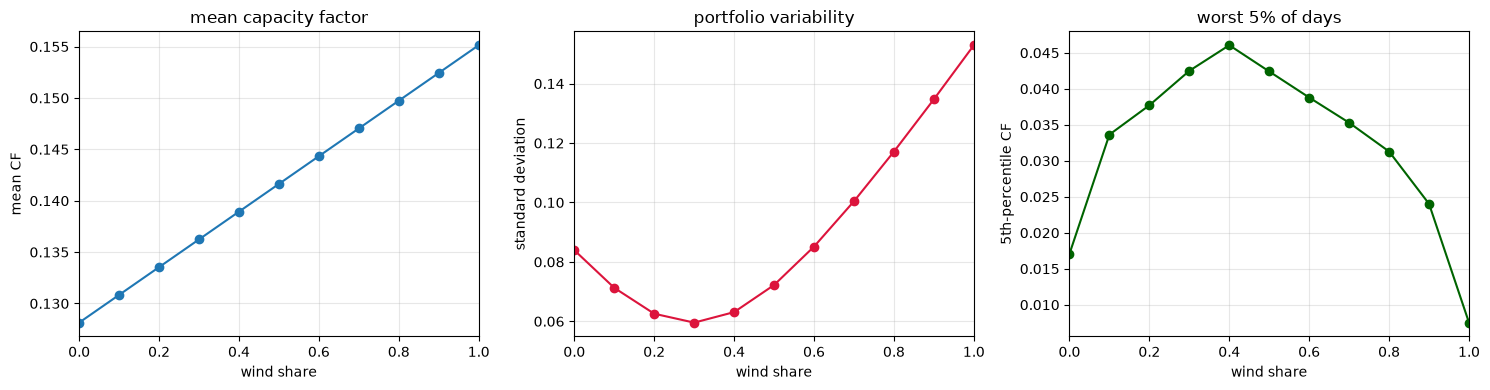

,wind_share,mean,std,q05,q10
0,0.0,0.128134,0.083937,0.017069,0.022826
1,0.1,0.130834,0.071271,0.033637,0.040002
2,0.2,0.133534,0.062559,0.037710,0.051814
3,0.3,0.136234,0.059564,0.042494,0.055446
4,0.4,0.138934,0.063103,0.046055,0.055154
5,0.5,0.141634,0.072224,0.042407,0.056154
6,0.6,0.144334,0.085151,0.038789,0.054927
7,0.7,0.147034,0.100424,0.035285,0.050147
8,0.8,0.149734,0.117130,0.031288,0.041850
9,0.9,0.152434,0.134737,0.024011,0.032025


In [3]:
wind_shares = np.arange(0.0, 1.01, 0.1)
mix_rows = []
for w in wind_shares:
    s = 1.0 - w
    mix = w * g["wind_cf"] + s * g["solar_cf"]
    mix_rows.append({
        "wind_share": w,
        "mean": float(mix.mean()),
        "std": float(mix.std()),
        "q05": float(mix.quantile(0.05)),
        "q10": float(mix.quantile(0.10)),
    })
mix = pd.DataFrame(mix_rows)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].plot(mix["wind_share"], mix["mean"], "o-")
axes[0].set_ylabel("mean CF")
axes[0].set_title("mean capacity factor")
axes[1].plot(mix["wind_share"], mix["std"], "o-", color="crimson")
axes[1].set_ylabel("standard deviation")
axes[1].set_title("portfolio variability")
axes[2].plot(mix["wind_share"], mix["q05"], "o-", color="darkgreen")
axes[2].set_ylabel("5th-percentile CF")
axes[2].set_title("worst 5% of days")
for ax in axes:
    ax.set_xlabel("wind share")
    ax.set_xlim(0, 1)
    ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

mix

## 4. Variance decomposition for the 50/50 mix

This decomposes the variance of the 50/50 portfolio into the wind variance, solar variance,
and the covariance term. A negative covariance means the two resources offset each other,
reducing total variance.

In [4]:
w, s = 0.5, 0.5
var_w = g["wind_cf"].var()
var_s = g["solar_cf"].var()
cov = g["wind_cf"].cov(g["solar_cf"])
var_mix = (w**2 * var_w) + (s**2 * var_s) + (2 * w * s * cov)

decomp = pd.DataFrame({
    "term": ["w²·Var(W)", "s²·Var(S)", "2ws·Cov(W,S)", "Var(50/50 mix)"],
    "value": [w**2 * var_w, s**2 * var_s, 2 * w * s * cov, var_mix],
})
decomp["value"] = decomp["value"].round(6)
decomp

,term,value
0,w²·Var(W),0.005847
1,s²·Var(S),0.001761
2,"2ws·Cov(W,S)",-0.002392
3,Var(50/50 mix),0.005216


## 5. Low-output CF exceedance metric

These empirical 2018 percentiles show the CF exceeded on 90% and 95% of days. Higher values
indicate a less extreme low-output tail in this resource proxy; they are not firm capacity,
capacity credit, or an operational reliability metric.

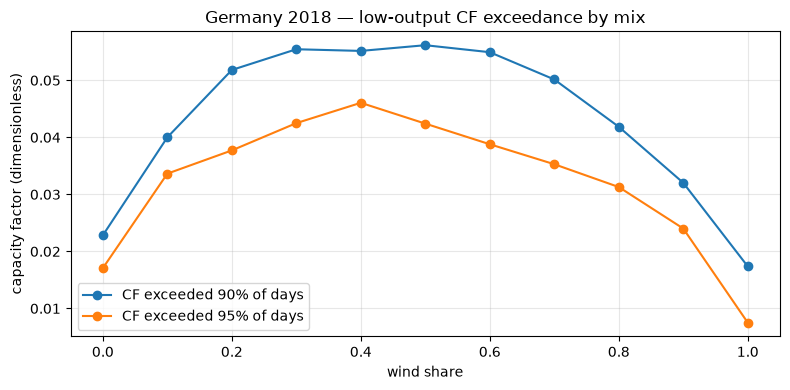

,wind_share,cf_exceeded_90_pct,cf_exceeded_95_pct
0,0.0,0.022826,0.017069
1,0.1,0.040002,0.033637
2,0.2,0.051814,0.037710
3,0.3,0.055446,0.042494
4,0.4,0.055154,0.046055
5,0.5,0.056154,0.042407
6,0.6,0.054927,0.038789
7,0.7,0.050147,0.035285
8,0.8,0.041850,0.031288
9,0.9,0.032025,0.024011


In [5]:
firm_rows = []
for w in wind_shares:
    s = 1.0 - w
    mix = w * g["wind_cf"] + s * g["solar_cf"]
    firm_rows.append({
        "wind_share": w,
        "cf_exceeded_90_pct": float(mix.quantile(0.10)),
        "cf_exceeded_95_pct": float(mix.quantile(0.05)),
    })
firm = pd.DataFrame(firm_rows)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(firm["wind_share"], firm["cf_exceeded_90_pct"], "o-", label="CF exceeded 90% of days")
ax.plot(firm["wind_share"], firm["cf_exceeded_95_pct"], "o-", label="CF exceeded 95% of days")
ax.set_xlabel("wind share")
ax.set_ylabel("capacity factor (dimensionless)")
ax.set_title("Germany 2018 — low-output CF exceedance by mix")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

firm

## 6. Dunkelflaute: threshold and duration sensitivity

We define a Dunkelflaute as consecutive days on which the combined capacity factor is below
an absolute threshold. The heatmap shows how the number of events and the maximum duration
change with threshold and minimum duration.

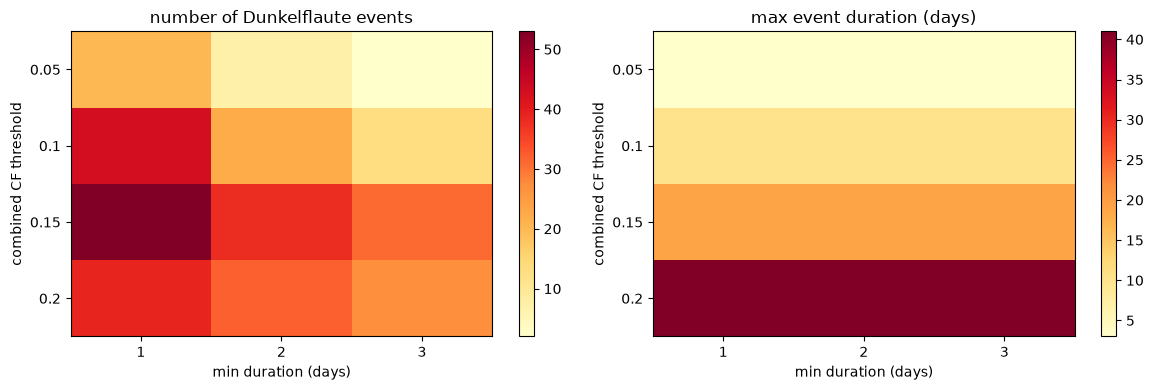

,1,2,3
threshold,,,
0.05,20,7,2
0.10,43,22,13
0.15,53,38,31
0.20,39,32,27


In [6]:
def find_events(series, threshold, min_duration):
    runs = []
    in_event = False
    start = None
    for date, val in series.items():
        if val < threshold and not in_event:
            start = date
            in_event = True
        elif val >= threshold and in_event:
            end = date - pd.Timedelta(days=1)
            length = (end - start).days + 1
            if length >= min_duration:
                runs.append(length)
            in_event = False
    if in_event:
        end = series.index[-1]
        length = (end - start).days + 1
        if length >= min_duration:
            runs.append(length)
    return pd.Series(runs, dtype=int)

thresholds = [0.05, 0.10, 0.15, 0.20]
min_durations = [1, 2, 3]
g_indexed = g.set_index("time")["combined_cf"]

count_rows = []
max_rows = []
for thr in thresholds:
    count_row = {"threshold": thr}
    max_row = {"threshold": thr}
    for dur in min_durations:
        ev = find_events(g_indexed, thr, dur)
        count_row[dur] = len(ev)
        max_row[dur] = int(ev.max()) if len(ev) else 0
    count_rows.append(count_row)
    max_rows.append(max_row)

count_df = pd.DataFrame(count_rows).set_index("threshold")
max_df = pd.DataFrame(max_rows).set_index("threshold")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
im1 = axes[0].imshow(count_df.values, aspect="auto", cmap="YlOrRd")
axes[0].set_xticks(range(len(min_durations)))
axes[0].set_xticklabels(min_durations)
axes[0].set_yticks(range(len(thresholds)))
axes[0].set_yticklabels(thresholds)
axes[0].set_xlabel("min duration (days)")
axes[0].set_ylabel("combined CF threshold")
axes[0].set_title("number of Dunkelflaute events")
plt.colorbar(im1, ax=axes[0])

im2 = axes[1].imshow(max_df.values, aspect="auto", cmap="YlOrRd")
axes[1].set_xticks(range(len(min_durations)))
axes[1].set_xticklabels(min_durations)
axes[1].set_yticks(range(len(thresholds)))
axes[1].set_yticklabels(thresholds)
axes[1].set_xlabel("min duration (days)")
axes[1].set_ylabel("combined CF threshold")
axes[1].set_title("max event duration (days)")
plt.colorbar(im2, ax=axes[1])
plt.tight_layout()
plt.show()

count_df

## 7. Dunkelflaute catalogue for the 10% / ≥2-day definition

This is the same definition used in the 2018 metrics. We show the longest events and the full
table is available as a DataFrame display.

In [7]:
def make_event_table(series, threshold, min_duration):
    records = []
    in_event = False
    start = None
    for date, val in series.items():
        if val < threshold and not in_event:
            start = date
            in_event = True
        elif val >= threshold and in_event:
            end = date - pd.Timedelta(days=1)
            length = (end - start).days + 1
            if length >= min_duration:
                records.append({
                    "start": start.strftime("%Y-%m-%d"),
                    "end": end.strftime("%Y-%m-%d"),
                    "duration_days": length,
                    "threshold": threshold,
                })
            in_event = False
    if in_event:
        end = series.index[-1]
        length = (end - start).days + 1
        if length >= min_duration:
            records.append({
                "start": start.strftime("%Y-%m-%d"),
                "end": end.strftime("%Y-%m-%d"),
                "duration_days": length,
                "threshold": threshold,
            })
    return pd.DataFrame(records)

events_10_2 = make_event_table(g_indexed, 0.10, 2)
events_10_2.sort_values("duration_days", ascending=False).head(10)

,start,end,duration_days,threshold
17,2018-10-31,2018-11-09,10,0.1
16,2018-10-15,2018-10-22,8,0.1
20,2018-12-14,2018-12-19,6,0.1
19,2018-11-22,2018-11-27,6,0.1
4,2018-02-06,2018-02-10,5,0.1
6,2018-02-16,2018-02-20,5,0.1
15,2018-10-06,2018-10-09,4,0.1
12,2018-09-01,2018-09-04,4,0.1
14,2018-09-12,2018-09-14,3,0.1
1,2018-01-20,2018-01-22,3,0.1


## 8. Zoom into the longest 2018 Dunkelflaute event

The plot shows wind, solar, and hypothetical 50/50 hybrid CF around the longest screening
event. The red band marks the event window. No conclusion about electricity shortage or the
need for storage, imports, or backup can be drawn without a power-system model.

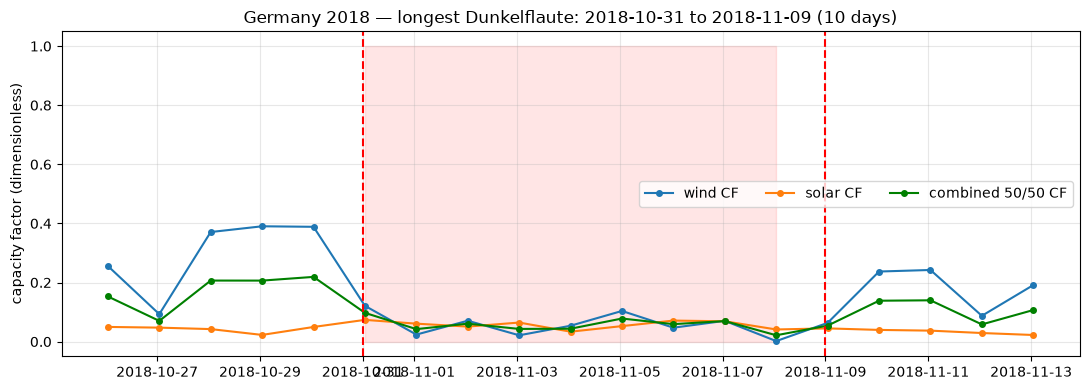

In [8]:
longest = events_10_2.sort_values("duration_days", ascending=False).iloc[0]
start, end = pd.Timestamp(longest["start"]), pd.Timestamp(longest["end"])
zoom = g_indexed.loc[start - pd.Timedelta(days=5) : end + pd.Timedelta(days=5)]

fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(zoom.index, g.set_index("time").loc[zoom.index, "wind_cf"], "o-", label="wind CF", markersize=4)
ax.plot(zoom.index, g.set_index("time").loc[zoom.index, "solar_cf"], "o-", label="solar CF", markersize=4)
ax.plot(zoom.index, zoom, "o-", color="green", label="combined 50/50 CF", markersize=4)
ax.axvline(start, color="red", linestyle="--")
ax.axvline(end, color="red", linestyle="--")
ax.fill_between(zoom.index, 0, 1, where=(zoom.index >= start) & (zoom.index <= end), alpha=0.1, color="red")
ax.set_ylabel("capacity factor (dimensionless)")
ax.set_title(f"Germany 2018 — longest Dunkelflaute: {start.date()} to {end.date()} ({longest['duration_days']} days)")
ax.legend(ncol=3)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 9. Spatial context: the season of the longest event

The longest event occurred in winter, so the winter-mean wind and GHI maps show the
background conditions. Red colours highlight the German land area within the DACH window.

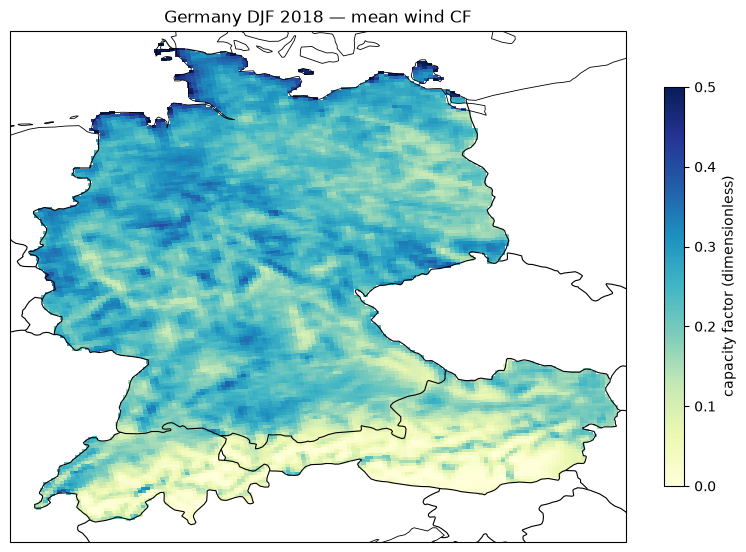

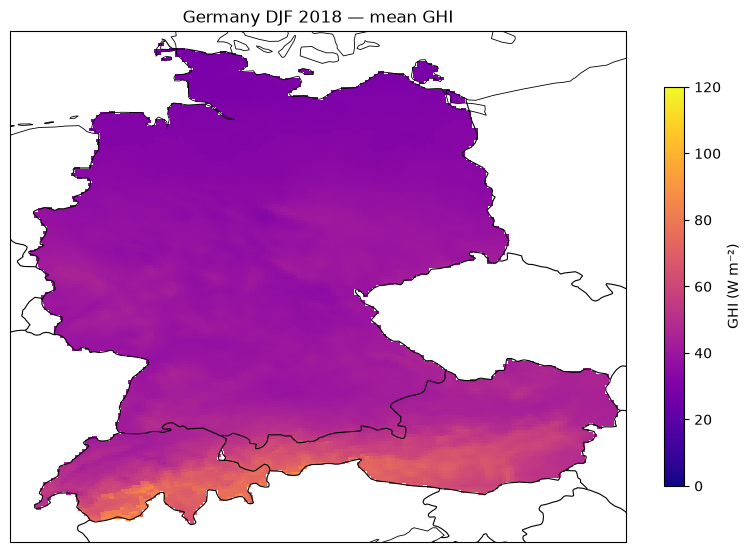

In [9]:
def plot_germany_field(ds, var, cmap, title, vmin, vmax):
    fig, ax = plt.subplots(figsize=(8, 6), subplot_kw={"projection": ccrs.PlateCarree()})
    im = ax.pcolormesh(
        ds.longitude, ds.latitude, ds[var],
        shading="auto", cmap=cmap, transform=ccrs.PlateCarree(),
        vmin=vmin, vmax=vmax,
    )
    ax.add_feature(cfeature.BORDERS.with_scale("50m"), linewidth=0.8, edgecolor="black")
    ax.add_feature(cfeature.COASTLINE.with_scale("50m"), linewidth=0.6, edgecolor="black")
    ax.set_extent([5.5, 17.25, 45.5, 55.25], crs=ccrs.PlateCarree())
    ax.set_title(title)
    unit_label = "capacity factor (dimensionless)" if var.endswith("_cf") else "GHI (W m⁻²)"
    plt.colorbar(im, ax=ax, shrink=0.7, label=unit_label)
    plt.tight_layout()
    plt.show()

winter = seasonal.sel(season="DJF")
plot_germany_field(winter, "wind_cf", "YlGnBu", "Germany DJF 2018 — mean wind CF", 0, 0.5)
plot_germany_field(winter, "ghi", "plasma", "Germany DJF 2018 — mean GHI", 0, 120)

## Key complementarity take-aways

- The full-year wind–solar correlation is negative, but much of it is the seasonal cycle. The
  weather-scale (monthly-anomaly) correlation is weaker, meaning day-to-day complementarity is
  more modest than the annual cycle suggests.
- The mix sweep is a **statistical sensitivity analysis for 2018**, not an economic or operational
  optimization. Different wind shares change the mean, variance, and low-output percentiles.
- Complementarity reduces variability under some hypothetical mixes, but it does not guarantee
  high output when both resources are weak.
- Dunkelflaute screening events are sensitive to threshold and minimum duration. Under the
  CF < 0.10 / ≥2-day definition, the longest area-weighted 2018 event lasts 10 days. One year
  cannot establish event frequency, rarity, or a climatology.